1. Define the Objective

Maximize portfolio return for a given level of risk (Mean-Variance Optimization) and identify optimal asset allocation.

2. Data Understanding & Collection

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load dataset
data = pd.read_csv('/content/drive/MyDrive/portfolio_datasets _24.02.2026.csv')

In [ ]:
# Preview
print(data.head())
print(data.info())
print(data.describe())

        AAPL   Date_AAPL       MSFT   Date_MSFT      GOOGL  Date_GOOGL  \
0  24.009062  2016-01-04  48.797722  2016-01-04  37.972000  2016-01-04   
1  23.407415  2016-01-05  49.020344  2016-01-05  38.076500  2016-01-05   
2  22.949339  2016-01-06  48.129879  2016-01-06  37.966499  2016-01-06   
3  21.980766  2016-01-07  46.455799  2016-01-07  37.049999  2016-01-07   
4  22.096992  2016-01-08  46.598251  2016-01-08  36.545502  2016-01-08   

        TSLA   Date_TSLA  
0  14.894000  2016-01-04  
1  14.895333  2016-01-05  
2  14.602667  2016-01-06  
3  14.376667  2016-01-07  
4  14.066667  2016-01-08  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1762 entries, 0 to 1761
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   AAPL        1762 non-null   float64
 1   Date_AAPL   1762 non-null   object 
 2   MSFT        1762 non-null   float64
 3   Date_MSFT   1762 non-null   object 
 4   GOOGL       1762 non-null   float64


In [ ]:
# Check missing values
print(data.isnull().sum())

AAPL          0
Date_AAPL     0
MSFT          0
Date_MSFT     0
GOOGL         0
Date_GOOGL    0
TSLA          0
Date_TSLA     0
dtype: int64


3. Data Preparation

In [ ]:
data = data.fillna(method='ffill')

/tmp/ipython-input-917065080.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill')


In [ ]:
#Normalisation
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numerical_cols = ['AAPL', 'MSFT', 'GOOGL', 'TSLA']
scaled_data = pd.DataFrame(
    scaler.fit_transform(data[numerical_cols]),
    columns=numerical_cols
)

4. DV & IV

DV: Portfolio return, portfolio risk

IV:Asset returns, asset weights

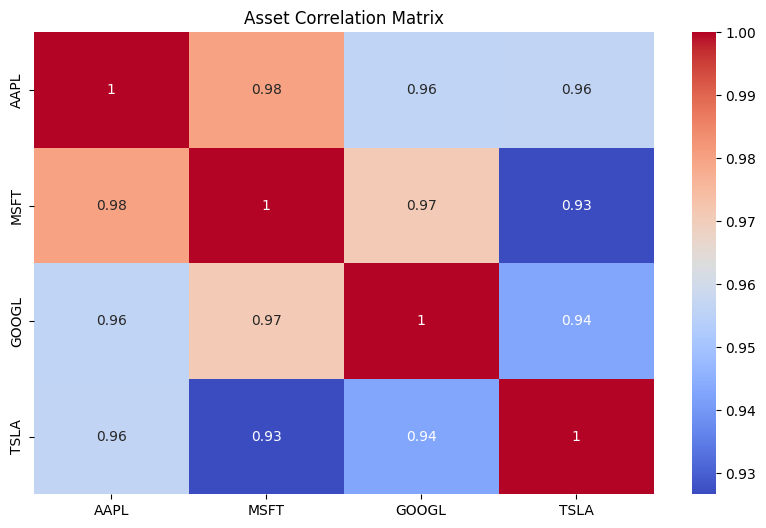

In [ ]:
# Correlation matrix
corr_matrix = scaled_data.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Asset Correlation Matrix")
plt.show()

5. Develop Model (Mean & Variance Optimization)

In [ ]:
# Calculate returns
returns = data[numerical_cols].pct_change().dropna()
mean_returns = returns.mean()
cov_matrix = returns.cov()
num_portfolios = 5000
results = np.zeros((3, num_portfolios))

for i in range(num_portfolios):
    weights = np.random.random(len(mean_returns))
    weights /= np.sum(weights)
    portfolio_return = np.sum(weights * mean_returns)
    portfolio_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    results[0,i] = portfolio_return
    results[1,i] = portfolio_std
    results[2,i] = portfolio_return / portfolio_std  # Sharpe Ratio

In [ ]:
# Extract optimal portfolio
max_sharpe_idx = np.argmax(results[2])
optimal_return = results[0, max_sharpe_idx]
optimal_risk = results[1, max_sharpe_idx]
print("Optimal Return:", optimal_return)
print("Optimal Risk:", optimal_risk)

Optimal Return: 0.0012572145641386238
Optimal Risk: 0.01845565964391495


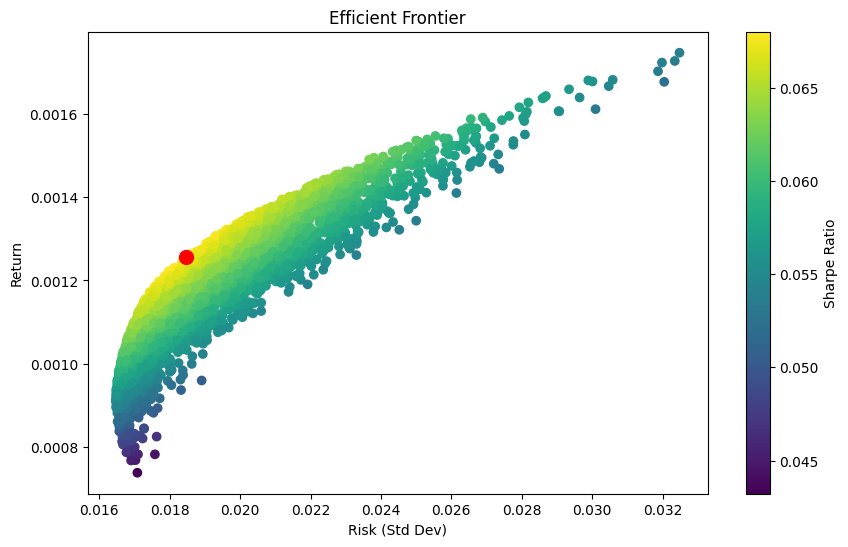

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis')
plt.colorbar(label='Sharpe Ratio')
plt.scatter(optimal_risk, optimal_return, color='red', s=100)
plt.xlabel("Risk (Std Dev)")
plt.ylabel("Return")
plt.title("Efficient Frontier")
plt.show()

6. Evaluation & Insights

In [ ]:
print("Sharpe Ratio of Optimal Portfolio:", results[2, max_sharpe_idx])

Sharpe Ratio of Optimal Portfolio: 0.06584961042310178


0.0658 indicates very weak risk-adjusted performance.

It means:

For every 1 unit of risk taken,

You are earning only 0.065 units of excess return.

That is almost negligible compensation for risk.

7. Evaluation & Insights

Assets with low correlation improve diversification.

Higher Sharpe Ratio indicates better risk-adjusted performance.

Efficient frontier shows optimal trade-off between risk & retur

 8. Suggestion & Conclusion

 Allocate more weight to assets contributing higher Sharpe.

Avoid highly correlated assets.

Periodically rebalance portfolio.

Conclusion :
Portfolio optimization improves capital allocation efficiency and risk-adjusted returns using quantitative modeling.